**Objective**: In this lab, you will implement and compare manual grid search with scikit-learn's built-in GridSearchCV for hyperparameter tuning. You'll work with multiple classification algorithms and combine them using voting classifiers.

**Learning Goals**:
- Understand hyperparameter tuning through grid search
- Compare manual implementation with built-in functions
- Learn to create and evaluate voting classifiers
- Work with multiple real-world datasets
- Visualize model performance using ROC curves and confusion matrices

**Datasets Used**:
1. Wine Quality - Predicting wine quality based on chemical properties
2. HR Attrition - Predicting employee turnover
3. Banknote Authentication - Detecting counterfeit banknotes
4. QSAR Biodegradation - Predicting chemical biodegradability



## Part 1: Import Libraries and Setup

First, let's import all the necessary libraries for our machine learning pipeline.

In [140]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
import warnings
warnings.filterwarnings("ignore", message="X has feature names")

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
# Bypass SSL certificate verification for dataset downloads
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Models and Parameter Grids

In [141]:
# The parameter names must match the pipeline step names, e.g., 'classifier__max_depth'
# TODO: Define base models (Decision Tree, kNN, Logistic Regression)

param_grid_dt = {'feature_selection__k': [5, 8, 11],        # up to all features
    'classifier__max_depth': [3, 5, 10, None], # controls tree complexity
    'classifier__min_samples_split': [2, 5, 10]
}

param_grid_knn = {
    'feature_selection__k': [5, 8, 11],
    'classifier__n_neighbors': [3, 5, 7, 9, 11],      # small odd numbers
    'classifier__weights': ['uniform', 'distance'],   # uniform vs distance weighting
    'classifier__metric': ['euclidean', 'manhattan']  # common distance metrics
    }

param_grid_lr = {'feature_selection__k': [5, 8, 11],
    'classifier__C': [0.01, 0.1, 1, 10],  # regularization strength
    'classifier__penalty': ['l2'],        # stable with lbfgs
    'classifier__solver': ['lbfgs'],      # supports l2, works well on this dataset
    'classifier__max_iter': [500]         # ensure convergence
                 }

# ToDo: Create a list of (classifier, param_grid, name) tuples
classifiers_to_tune = [(DecisionTreeClassifier(),param_grid_dt,"DecisionTrees"),(KNeighborsClassifier(), param_grid_knn,"KNearestNeighbors"),
                       (LogisticRegression(),param_grid_lr,"LogisticReg.")]

## Dataset Loading Functions
We'll work with four different datasets to test our algorithms across various domains.

### 3.1 Wine Quality Dataset


In [142]:
def load_wine_quality():
    """Load Wine Quality dataset"""
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        data = pd.read_csv(url, sep=';')
    except Exception as e:
        print(f"Error loading Wine Quality dataset: {e}")
        return None, None, None, None, "Wine Quality (Failed)"

    # Create the binary target variable 'good_quality'
    data['good_quality'] = (data['quality'] > 5).astype(int)
    X = data.drop(['quality', 'good_quality'], axis=1)
    y = data['good_quality']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print("Wine Quality dataset loaded and preprocessed successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "Wine Quality"

## Part 4: Manual Grid Search Implementation



In [143]:
import itertools
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score

def run_manual_grid_search(X_train, y_train, dataset_name):


  # ensure numpy arrays
    if not isinstance(X_train, np.ndarray):
      X_train = X_train.to_numpy()
    if not isinstance(y_train, np.ndarray):
      y_train = y_train.to_numpy()


    """Run manual grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING MANUAL GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    best_estimators = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Adjust parameter grids based on dataset size
    n_features = X_train.shape[1]

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"--- Manual Grid Search for {name} ---")
        best_score = -1
        best_params = None

        # Step 1: Adjust feature selection grid (if present)
        adjusted_param_grid = {}
        for param, values in param_grid.items():
            if "feature_selection__k" in param:
                adjusted_param_grid[param] = [v for v in values if v <= n_features]
                if not adjusted_param_grid[param]:  # if all values > n_features
                    adjusted_param_grid[param] = [n_features]  # fallback
            else:
                adjusted_param_grid[param] = values

        # Step 2: Generate all parameter combinations
        keys, values = zip(*adjusted_param_grid.items()) if adjusted_param_grid else ([], [])
        param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)] if keys else [{}]

        # Step 3: Evaluate each parameter combination
        for params in param_combinations:
            auc_scores = []

            for train_idx, val_idx in cv.split(X_train, y_train):
                X_tr, X_val = X_train[train_idx], X_train[val_idx]
                y_tr, y_val = y_train[train_idx], y_train[val_idx]

                pipeline = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(f_classif)),
                    ('classifier', classifier_instance)
                ])

                # Set current parameters
                pipeline.set_params(**params)

                # Train and evaluate
                pipeline.fit(X_tr, y_tr)
                y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
                auc = roc_auc_score(y_val, y_pred_proba)
                auc_scores.append(auc)

            mean_auc = np.mean(auc_scores)

            if mean_auc > best_score:
                best_score = mean_auc
                best_params = params

        # Step 4: Report and build final pipeline
        print("-" * 90)
        print(f"Best parameters for {name}: {best_params}")
        print(f"Best cross-validation AUC: {best_score:.4f}")

        final_pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(f_classif)),
            ('classifier', classifier_instance)
        ])

        # Apply best params
        final_pipeline.set_params(**best_params)

        # Retrain on full training set
        final_pipeline.fit(X_train, y_train)

        best_estimators[name] = final_pipeline

    return best_estimators


**Understanding the Manual Implementation**:
- **Nested Cross-Validation**: For each parameter combination, we perform 5-fold CV
- **Pipeline Integration**: Each step (scaling, feature selection, classification) is properly chained
- **AUC Scoring**: We use Area Under the ROC Curve as our optimization metric
- **Best Model Selection**: The combination with highest mean AUC across folds is selected

## Part 5: Built-in Grid Search Implementation

Now let's compare our manual implementation with scikit-learn's GridSearchCV.



**Advantages of Built-in GridSearchCV**:
- **Parallel Processing**: Uses `n_jobs=-1` for faster computation
- **Cleaner Code**: Less verbose than manual implementation
- **Built-in Features**: Automatic best model selection and scoring


In [144]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

def run_builtin_grid_search(X_train, y_train, dataset_name):
    """Run built-in grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING BUILT-IN GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    results_builtin = {}

    # Adjust parameter grids based on dataset size
    n_features = X_train.shape[1]

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"\n--- GridSearchCV for {name} ---")

        # Step 1: Adjust param grid (especially feature_selection__k)
        adjusted_param_grid = {}
        for param, values in param_grid.items():
            if "feature_selection__k" in param:
                adjusted_param_grid[param] = [v for v in values if v <= n_features]
                if not adjusted_param_grid[param]:  # fallback if empty
                    adjusted_param_grid[param] = [n_features]
            else:
                adjusted_param_grid[param] = values

        # Step 2: Create pipeline
        pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(f_classif)),
            ('classifier', classifier_instance)
        ])

        # Step 3: CV splitter
        cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Step 4: GridSearchCV setup
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=adjusted_param_grid,
            cv=cv_splitter,
            scoring='roc_auc',
            n_jobs=-1,        # parallel jobs
            verbose=1         # progress output
        )

        # Step 5: Fit
        grid_search.fit(X_train, y_train)

        # Step 6: Save results
        results_builtin[name] = {
            'best_estimator': grid_search.best_estimator_,
            'best_score (CV)': grid_search.best_score_,
            'best_params': grid_search.best_params_
        }

        print(f"Best params for {name}: {results_builtin[name]['best_params']}")
        print(f"Best CV score: {results_builtin[name]['best_score (CV)']:.4f}")

    return results_builtin


## Part 6: Model Evaluation and Voting Classifiers

This function evaluates individual models and creates voting classifiers to combine their predictions.




In [145]:
# Part 6: Model Evaluation and Voting Classifiers

def evaluate_models(X_test, y_test, best_estimators, dataset_name, method_name="Manual", X_train=None, y_train=None):
    print(f"\n{'='*60}\nEVALUATING {method_name.upper()} MODELS FOR {dataset_name.upper()}\n{'='*60}")
    for name, model in best_estimators.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        print(f"\n{name}:")
        print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f" Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
        print(f" Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
        print(f" F1-Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
        print(f" ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"\n--- {method_name} Voting Classifier ---")

    if method_name == "Manual":
        y_pred_votes, y_pred_proba_avg = [], []
        for i in range(len(X_test)):
            votes, probas = [], []
            for model in best_estimators.values():
                pred = model.predict(X_test.iloc[[i]])
                proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
                votes.append(pred)
                probas.append(proba)
            majority_vote = 1 if np.mean(votes) > 0.5 else 0
            avg_proba = np.mean(probas)
            y_pred_votes.append(majority_vote)
            y_pred_proba_avg.append(avg_proba)
        y_pred_votes = np.array(y_pred_votes)
        y_pred_proba_avg = np.array(y_pred_proba_avg)
    else:
        estimators = [(name, model) for name, model in best_estimators.items()]
        voting_clf = VotingClassifier(estimators=estimators, voting='soft')
        voting_clf.fit(X_train, y_train)
        y_pred_votes = voting_clf.predict(X_test)
        y_pred_proba_avg = voting_clf.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_votes)
    precision = precision_score(y_test, y_pred_votes, zero_division=0)
    recall = recall_score(y_test, y_pred_votes, zero_division=0)
    f1 = f1_score(y_test, y_pred_votes, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba_avg)
    print(f"Voting Classifier Performance:")
    print(f" Accuracy: {accuracy:.4f}, Precision: {precision:.4f}")
    print(f" Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for name, model in best_estimators.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
    fpr_vote, tpr_vote, _ = roc_curve(y_test, y_pred_proba_avg)
    plt.plot(fpr_vote, tpr_vote, label=f'Voting (AUC = {auc:.3f})', linewidth=3, linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {dataset_name} ({method_name})')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred_votes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), cmap="Blues")
    plt.title(f'Voting Classifier - {dataset_name} ({method_name})')

    plt.tight_layout()
    plt.show()
    return y_pred_votes, y_pred_proba_avg

## Part 7: Complete Pipeline Function

This function orchestrates the entire experiment for each dataset.



In [146]:
# Part 7: Complete Pipeline Function

def run_complete_pipeline(dataset_loader, dataset_name):
    print(f"\n{'#'*80}\nPROCESSING DATASET: {dataset_name.upper()}\n{'#'*80}")
    X_train, X_test, y_train, y_test, actual_name = dataset_loader()
    if X_train is None:
        print(f"Skipping {dataset_name} due to loading error.")
        return
    print("-" * 30)
    manual_estimators = run_manual_grid_search(X_train, y_train, actual_name)
    manual_votes, manual_proba = evaluate_models(X_test, y_test, manual_estimators, actual_name, "Manual")
    builtin_results = run_builtin_grid_search(X_train, y_train, actual_name)
    builtin_estimators = {name: results['best_estimator'] for name, results in builtin_results.items()}
    builtin_votes, builtin_proba = evaluate_models(X_test, y_test, builtin_estimators, actual_name, "Built-in", X_train, y_train)
    print(f"\nCompleted processing for {actual_name}")
    print("="*80)

## Part 8: Execute the Complete Lab

Now let's run our pipeline on all four datasets!




################################################################################
PROCESSING DATASET: WINE QUALITY
################################################################################
Wine Quality dataset loaded and preprocessed successfully.
Training set shape: (1119, 11)
Testing set shape: (480, 11)
------------------------------

RUNNING MANUAL GRID SEARCH FOR WINE QUALITY
--- Manual Grid Search for DecisionTrees ---
------------------------------------------------------------------------------------------
Best parameters for DecisionTrees: {'feature_selection__k': 5, 'classifier__max_depth': 5, 'classifier__min_samples_split': 2}
Best cross-validation AUC: 0.7831
--- Manual Grid Search for KNearestNeighbors ---
------------------------------------------------------------------------------------------
Best parameters for KNearestNeighbors: {'feature_selection__k': 5, 'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'classifier__metric': 'manhattan'}
Best

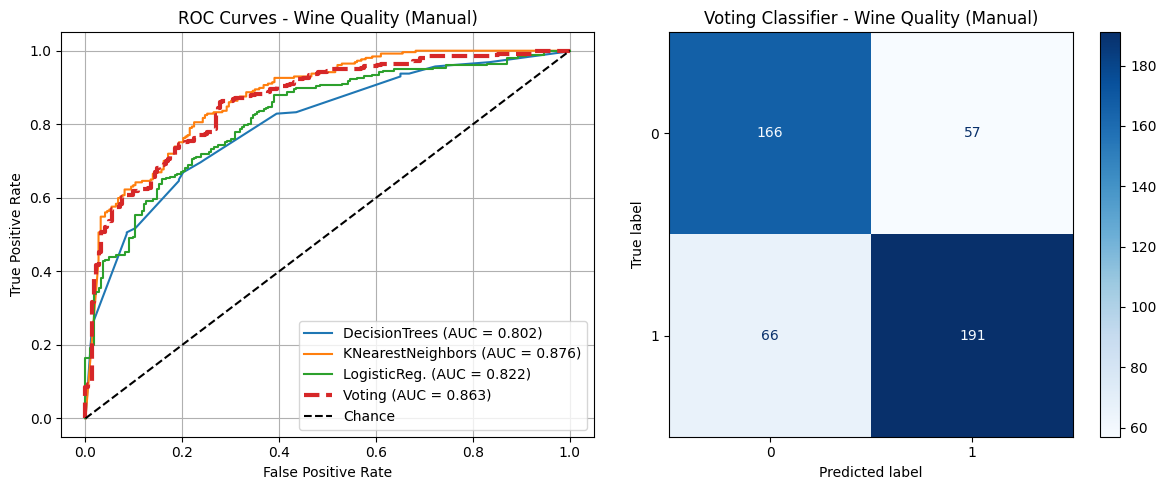


RUNNING BUILT-IN GRID SEARCH FOR WINE QUALITY

--- GridSearchCV for DecisionTrees ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for DecisionTrees: {'classifier__max_depth': 5, 'classifier__min_samples_split': 10, 'feature_selection__k': 5}
Best CV score: 0.7826

--- GridSearchCV for KNearestNeighbors ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params for KNearestNeighbors: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'feature_selection__k': 5}
Best CV score: 0.8696

--- GridSearchCV for LogisticReg. ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params for LogisticReg.: {'classifier__C': 10, 'classifier__max_iter': 500, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'feature_selection__k': 8}
Best CV score: 0.8082

EVALUATING BUILT-IN MODELS FOR WINE QUALITY

DecisionTrees:
 Accuracy: 0.7271
 Precision: 0.7716
 Recall: 0.6965
 F1-Score

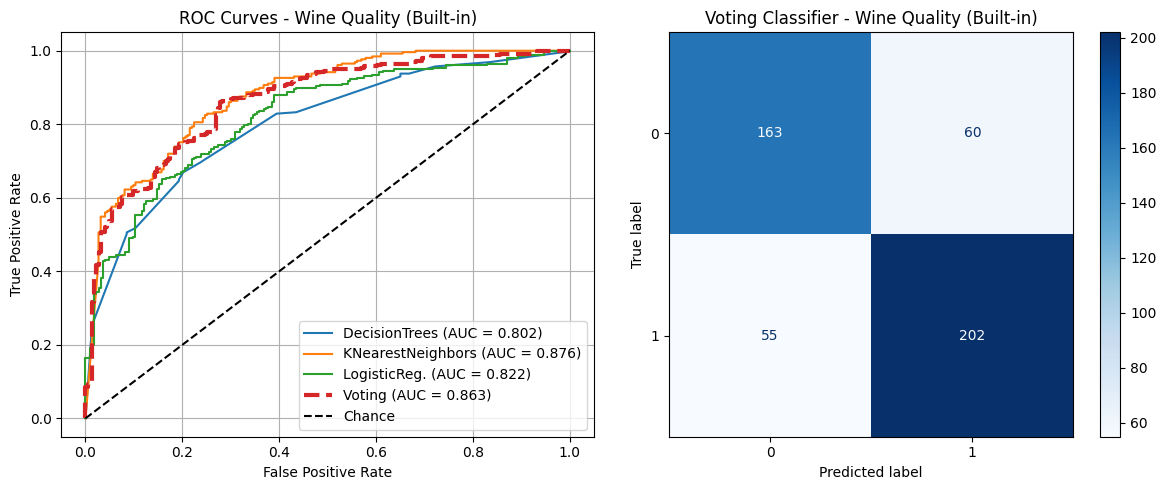


Completed processing for Wine Quality

ALL DATASETS PROCESSED!


In [147]:
# --- Run Pipeline for All Datasets ---
datasets = [
    (load_wine_quality, "Wine Quality")
]

# Run for each dataset
for dataset_loader, dataset_name in datasets:
    try:
        run_complete_pipeline(dataset_loader, dataset_name)
    except Exception as e:
        print(f"Error processing {dataset_name}: {e}")
        continue

print("\n" + "="*80)
print("ALL DATASETS PROCESSED!")
print("="*80)